<a href="https://colab.research.google.com/github/rka0285058-afk/Pasture-Bio-Mass-Prediction/blob/main/Bio_Mass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
train_df = pd.read_csv('/content/drive/MyDrive/Australia_BioMass/csiro-biomass/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Australia_BioMass/csiro-biomass/test.csv')
test_level_df = pd.read_csv('/content/drive/MyDrive/Australia_BioMass/csiro-biomass/sample_submission (1).csv')

In [ ]:
print(X_train_new.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 1723 to 1126
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Pre_GSHH_NDVI                          1428 non-null   float64
 1   Height_Ave_cm                          1428 non-null   float64
 2   encoded_State                          1428 non-null   int64  
 3   encoded_Species                        1428 non-null   int64  
 4   year                                   1428 non-null   float64
 5   month                                  1428 non-null   float64
 6   day                                    1428 non-null   float64
 7   dayofweek                              1428 non-null   float64
 8   dayofyear                              1428 non-null   float64
 9   NDVI_Height_Interaction                1428 non-null   float64
 10  Pre_GSHH_NDVI                          1428 non-null   float64
 11  Height

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train the XGBoost Regressor model with engineered features
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_new, y_train_new)

# Make predictions on the validation set
y_pred_xgb = xgb_model.predict(X_val_new)

# Evaluate the model
mae_xgb = mean_absolute_error(y_val_new, y_pred_xgb)
r2_xgb = r2_score(y_val_new, y_pred_xgb)

print(f"XGBoost - Mean Absolute Error on validation set: {mae_xgb:.4f}")
print(f"XGBoost - R-squared on validation set: {r2_xgb:.4f}")

XGBoost - Mean Absolute Error on validation set: 18.8002
XGBoost - R-squared on validation set: 0.1041


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train the RandomForestRegressor model with new features
model_new_features = RandomForestRegressor(random_state=42)
model_new_features.fit(X_train_new, y_train_new)

# Make predictions on the validation set with new features
y_pred_new_features = model_new_features.predict(X_val_new)

# Evaluate the model with new features
mae_new_features = mean_absolute_error(y_val_new, y_pred_new_features)
r2_new_features = r2_score(y_val_new, y_pred_new_features)

print(f"Mean Absolute Error on validation set (with new features): {mae_new_features:.4f}")
print(f"R-squared on validation set (with new features): {r2_new_features:.4f}")

Mean Absolute Error on validation set (with new features): 18.4359
R-squared on validation set (with new features): 0.1362


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_new, y_train_new)

# Make predictions on the validation set
y_pred = model.predict(X_val_new)

# Evaluate the model
mae = mean_absolute_error(y_val_new, y_pred)
r2 = r2_score(y_val_new, y_pred)

print(f"Mean Absolute Error on validation set: {mae:.4f}")
print(f"R-squared on validation set: {r2:.4f}")

Mean Absolute Error on validation set: 18.4351
R-squared on validation set: 0.1330


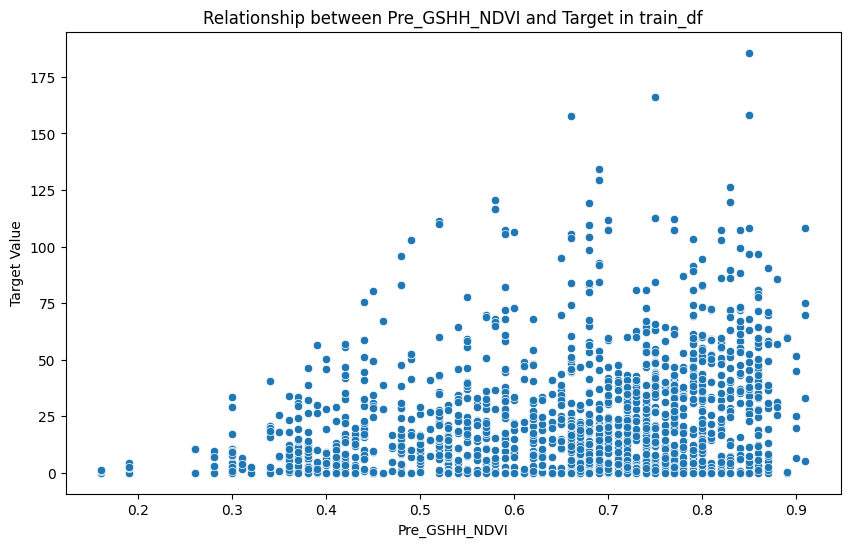

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pre_GSHH_NDVI', y='target', data=train_df)
plt.title('Relationship between Pre_GSHH_NDVI and Target in train_df')
plt.xlabel('Pre_GSHH_NDVI')
plt.ylabel('Target Value')
plt.show()

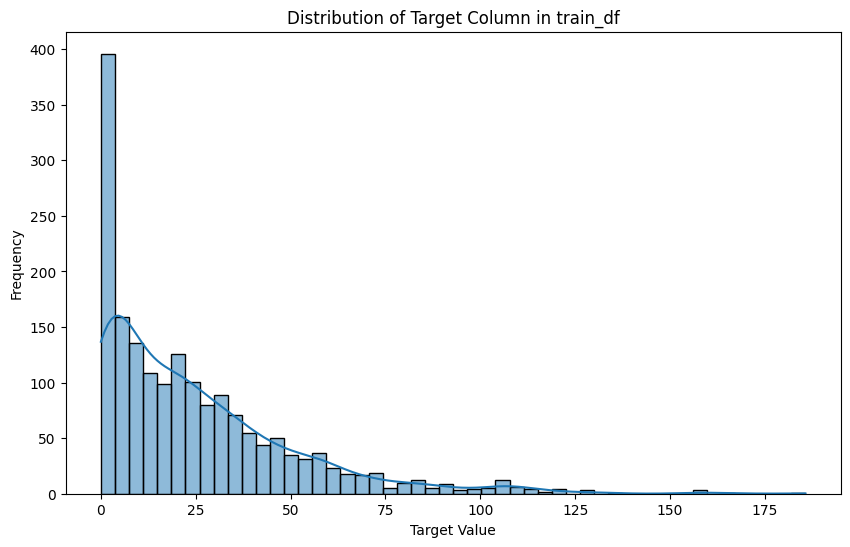

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(train_df['target'], kde=True, bins=50)
plt.title('Distribution of Target Column in train_df')
plt.xlabel('Target Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
display(test_df.describe())

,Pre_GSHH_NDVI,Height_Ave_cm
count,5.000000,5.000000
mean,0.656625,7.465897
std,0.000000,0.000000
min,0.656625,7.465897
25%,0.656625,7.465897
50%,0.656625,7.465897
75%,0.656625,7.465897
max,0.656625,7.465897


In [ ]:
missing_values = train_df.isnull().sum()
print("Missing values in train_df:")
print(missing_values[missing_values > 0])

Missing values in train_df:
Series([], dtype: int64)


In [ ]:
y = train_df['target']
X = train_df[['Pre_GSHH_NDVI', 'Height_Ave_cm']]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Shape of X: (1785, 2)
Shape of y: (1785,)

First 5 rows of X:


,Pre_GSHH_NDVI,Height_Ave_cm
0,0.62,4.6667
1,0.62,4.6667
2,0.62,4.6667
3,0.62,4.6667
4,0.62,4.6667



First 5 rows of y:


,target
0,0.0000
1,31.9984
2,16.2751
3,48.2735
4,16.2750


In [ ]:
missing_values_test = test_df.isnull().sum()
print("Missing values in test_df:")
print(missing_values_test[missing_values_test > 0])

Missing values in test_df:
Series([], dtype: int64)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Create a new DataFrame X_new by copying X
X_new = X.copy()

# Create a new DataFrame for test data by copying test_df
test_df_processed = test_df.copy()

# Extract State and Species information per image_id from train_df
image_info = train_df[['image_id', 'State', 'Species']].drop_duplicates()

# Merge this information into test_df_processed
test_df_processed = pd.merge(test_df_processed, image_info, on='image_id', how='left')

# Impute NaN values in 'State' and 'Species' columns of test_df_processed with the mode from train_df
mode_state_train = train_df['State'].mode()[0]
mode_species_train = train_df['Species'].mode()[0]

test_df_processed['State'].fillna(mode_state_train, inplace=True)
test_df_processed['Species'].fillna(mode_species_train, inplace=True)

# Initialize and apply LabelEncoder for 'State' column
le_state = LabelEncoder()
X_new['encoded_State'] = le_state.fit_transform(train_df['State'])
test_df_processed['encoded_State'] = le_state.transform(test_df_processed['State'])

# Initialize and apply LabelEncoder for 'Species' column
le_species = LabelEncoder()
X_new['encoded_Species'] = le_species.fit_transform(train_df['Species'])
test_df_processed['encoded_Species'] = le_species.transform(test_df_processed['Species'])

print("First 5 rows of X_new with encoded features:")
display(X_new.head())

print("\nFirst 5 rows of test_df_processed with encoded features:")
display(test_df_processed.head())

First 5 rows of X_new with encoded features:


/tmp/ipython-input-4286164476.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df_processed['State'].fillna(mode_state_train, inplace=True)
/tmp/ipython-input-4286164476.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species
0,0.62,4.6667,1,11
1,0.62,4.6667,1,11
2,0.62,4.6667,1,11
3,0.62,4.6667,1,11
4,0.62,4.6667,1,11



First 5 rows of test_df_processed with encoded features:


,sample_id,image_path,target_name,image_id,Pre_GSHH_NDVI,Height_Ave_cm,State,Species,encoded_State,encoded_Species
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g,ID1001187975,0.656625,7.465897,Tas,Ryegrass_Clover,1,11
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g,ID1001187975,0.656625,7.465897,Tas,Ryegrass_Clover,1,11
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g,ID1001187975,0.656625,7.465897,Tas,Ryegrass_Clover,1,11
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g,ID1001187975,0.656625,7.465897,Tas,Ryegrass_Clover,1,11
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g,ID1001187975,0.656625,7.465897,Tas,Ryegrass_Clover,1,11


**Reasoning**:
The previous step successfully encoded the categorical features 'State' and 'Species' and added them to `X_new` and `test_df_processed`. The next logical step is to ensure `X_new` (for training) and `test_df_processed` (for prediction) explicitly include all the relevant numerical and newly encoded categorical features, and then display their structure to confirm.



In [ ]:
X_new = X_new[['Pre_GSHH_NDVI', 'Height_Ave_cm', 'encoded_State', 'encoded_Species']]
test_df_processed = test_df_processed[['Pre_GSHH_NDVI', 'Height_Ave_cm', 'encoded_State', 'encoded_Species']]

print("Features for training (X_new):")
display(X_new.head())
print("\nFeatures for testing (test_df_processed):")
display(test_df_processed.head())

print("Shape of X_new:", X_new.shape)
print("Shape of test_df_processed:", test_df_processed.shape)

Features for training (X_new):


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species
0,0.62,4.6667,1,11
1,0.62,4.6667,1,11
2,0.62,4.6667,1,11
3,0.62,4.6667,1,11
4,0.62,4.6667,1,11



Features for testing (test_df_processed):


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species
0,0.656625,7.465897,1,11
1,0.656625,7.465897,1,11
2,0.656625,7.465897,1,11
3,0.656625,7.465897,1,11
4,0.656625,7.465897,1,11


Shape of X_new: (1785, 4)
Shape of test_df_processed: (5, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define numerical features
numerical_features = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

# Initialize the StandardScaler
scaler = StandardScaler()

print("StandardScaler initialized and numerical features identified.")

StandardScaler initialized and numerical features identified.


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("Shape of X_train_new:", X_train_new.shape)
print("Shape of X_val_new:", X_val_new.shape)
print("Shape of y_train_new:", y_train_new.shape)
print("Shape of y_val_new:", y_val_new.shape)

Shape of X_train_new: (1428, 4)
Shape of X_val_new: (357, 4)
Shape of y_train_new: (1428,)
Shape of y_val_new: (357,)


In [ ]:
X_train_new[numerical_features] = scaler.fit_transform(X_train_new[numerical_features])
X_val_new[numerical_features] = scaler.transform(X_val_new[numerical_features])
test_df_processed[numerical_features] = scaler.transform(test_df_processed[numerical_features])

print("Scaled X_train_new (first 5 rows):")
display(X_train_new.head())

print("\nScaled X_val_new (first 5 rows):")
display(X_val_new.head())

print("\nScaled test_df_processed (first 5 rows):")
display(test_df_processed.head())

Scaled X_train_new (first 5 rows):


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species
1723,0.349184,-0.547973,2,11
175,0.545446,-0.046708,2,7
886,0.414605,2.760380,0,3
1604,1.068810,1.056077,2,11
481,0.545446,4.464682,0,3



Scaled X_val_new (first 5 rows):


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species
1374,-0.762964,-0.547973,1,14
1080,0.349184,-0.447720,2,11
1519,1.199650,0.354305,0,2
289,0.676287,-0.447720,2,11
990,0.022082,2.459620,0,5



Scaled test_df_processed (first 5 rows):


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species
0,0.0,0.0,1,11
1,0.0,0.0,1,11
2,0.0,0.0,1,11
3,0.0,0.0,1,11
4,0.0,0.0,1,11


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Re-initialize X_new and test_df_processed
X_new = X.copy()
test_df_processed = test_df.copy()

# 2. Extract unique image_id, State, and Species from train_df
image_info = train_df[['image_id', 'State', 'Species', 'Sampling_Date']].drop_duplicates()

# 3. Merge image_info into test_df_processed
test_df_processed = pd.merge(test_df_processed, image_info[['image_id', 'State', 'Species', 'Sampling_Date']], on='image_id', how='left')

# 4. Calculate the mode of the 'State' column from train_df
mode_state_train = train_df['State'].mode()[0]

# 5. Calculate the mode of the 'Species' column from train_df
mode_species_train = train_df['Species'].mode()[0]

# 6. Impute any missing values (NaN) in the 'State' column of test_df_processed
test_df_processed['State'].fillna(mode_state_train, inplace=True)

# 7. Impute any missing values (NaN) in the 'Species' column of test_df_processed
test_df_processed['Species'].fillna(mode_species_train, inplace=True)

# 8. Initialize and apply LabelEncoder for 'State' column
le_state = LabelEncoder()
X_new['encoded_State'] = le_state.fit_transform(train_df['State'])
test_df_processed['encoded_State'] = le_state.transform(test_df_processed['State'])

# 9. Initialize and apply LabelEncoder for 'Species' column
le_species = LabelEncoder()
X_new['encoded_Species'] = le_species.fit_transform(train_df['Species'])
test_df_processed['encoded_Species'] = le_species.transform(test_df_processed['Species'])

# 10. Convert the 'Sampling_Date' column in train_df to datetime objects
train_df['Sampling_Date'] = pd.to_datetime(train_df['Sampling_Date'])

# 11. Extract date features for X_new
X_new['year'] = train_df['Sampling_Date'].dt.year
X_new['month'] = train_df['Sampling_Date'].dt.month
X_new['day'] = train_df['Sampling_Date'].dt.day
X_new['dayofweek'] = train_df['Sampling_Date'].dt.dayofweek
X_new['dayofyear'] = train_df['Sampling_Date'].dt.dayofyear

# 12. Create a DataFrame image_sampling_date_map containing unique image_id and Sampling_Date from train_df
# This step was implicitly handled by including 'Sampling_Date' in image_info and merging in step 3.

# 13. Merge image_sampling_date_map into test_df_processed
# Done in step 3.

# 14. Calculate the mode of the 'Sampling_Date' column from train_df
mode_sampling_date_train = train_df['Sampling_Date'].mode()[0]

# 15. Impute any missing values (NaN) in the 'Sampling_Date' column of test_df_processed
test_df_processed['Sampling_Date'].fillna(mode_sampling_date_train, inplace=True)

# 16. Ensure the 'Sampling_Date' column in test_df_processed is of datetime type
test_df_processed['Sampling_Date'] = pd.to_datetime(test_df_processed['Sampling_Date'])

# 17. Extract date features for test_df_processed
test_df_processed['year'] = test_df_processed['Sampling_Date'].dt.year
test_df_processed['month'] = test_df_processed['Sampling_Date'].dt.month
test_df_processed['day'] = test_df_processed['Sampling_Date'].dt.day
test_df_processed['dayofweek'] = test_df_processed['Sampling_Date'].dt.dayofweek
test_df_processed['dayofyear'] = test_df_processed['Sampling_Date'].dt.dayofyear

# 18. Define a list final_features
final_features = ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'encoded_State', 'encoded_Species', 'year', 'month', 'day', 'dayofweek', 'dayofyear']

# 19. Update X_new to include only the columns specified in final_features
X_new = X_new[final_features]

# 20. Update test_df_processed to include only the columns specified in final_features
test_df_processed = test_df_processed[final_features]

# 21. Display the first 5 rows of X_new and test_df_processed
print("First 5 rows of X_new with engineered features:")
display(X_new.head())

print("\nFirst 5 rows of test_df_processed with engineered features:")
display(test_df_processed.head())

# 22. Print the shapes of X_new and test_df_processed
print("\nShape of X_new:", X_new.shape)
print("Shape of test_df_processed:", test_df_processed.shape)


First 5 rows of X_new with engineered features:


/tmp/ipython-input-1270999333.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df_processed['State'].fillna(mode_state_train, inplace=True)
/tmp/ipython-input-1270999333.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear
0,0.62,4.6667,1,11,2015,9,4,4,247
1,0.62,4.6667,1,11,2015,9,4,4,247
2,0.62,4.6667,1,11,2015,9,4,4,247
3,0.62,4.6667,1,11,2015,9,4,4,247
4,0.62,4.6667,1,11,2015,9,4,4,247



First 5 rows of test_df_processed with engineered features:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear
0,0.656625,7.465897,1,11,2015,6,26,4,177
1,0.656625,7.465897,1,11,2015,6,26,4,177
2,0.656625,7.465897,1,11,2015,6,26,4,177
3,0.656625,7.465897,1,11,2015,6,26,4,177
4,0.656625,7.465897,1,11,2015,6,26,4,177



Shape of X_new: (1785, 9)
Shape of test_df_processed: (5, 9)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Re-initialize X_new and test_df_processed
X_new = X.copy()
test_df_processed = test_df.copy()

# 2. Extract unique image_id, State, and Species from train_df
image_info = train_df[['image_id', 'State', 'Species', 'Sampling_Date']].drop_duplicates()

# 3. Merge image_info into test_df_processed
test_df_processed = pd.merge(test_df_processed, image_info[['image_id', 'State', 'Species', 'Sampling_Date']], on='image_id', how='left')

# 4. Calculate the mode of the 'State' column from train_df
mode_state_train = train_df['State'].mode()[0]

# 5. Calculate the mode of the 'Species' column from train_df
mode_species_train = train_df['Species'].mode()[0]

# 6. Impute any missing values (NaN) in the 'State' column of test_df_processed
test_df_processed['State'] = test_df_processed['State'].fillna(mode_state_train)

# 7. Impute any missing values (NaN) in the 'Species' column of test_df_processed
test_df_processed['Species'] = test_df_processed['Species'].fillna(mode_species_train)

# 8. Initialize and apply LabelEncoder for 'State' column
le_state = LabelEncoder()
X_new['encoded_State'] = le_state.fit_transform(train_df['State'])
test_df_processed['encoded_State'] = le_state.transform(test_df_processed['State'])

# 9. Initialize and apply LabelEncoder for 'Species' column
le_species = LabelEncoder()
X_new['encoded_Species'] = le_species.fit_transform(train_df['Species'])
test_df_processed['encoded_Species'] = le_species.transform(test_df_processed['Species'])

# 10. Convert the 'Sampling_Date' column in train_df to datetime objects
train_df['Sampling_Date'] = pd.to_datetime(train_df['Sampling_Date'])

# 11. Extract date features for X_new
X_new['year'] = train_df['Sampling_Date'].dt.year
X_new['month'] = train_df['Sampling_Date'].dt.month
X_new['day'] = train_df['Sampling_Date'].dt.day
X_new['dayofweek'] = train_df['Sampling_Date'].dt.dayofweek
X_new['dayofyear'] = train_df['Sampling_Date'].dt.dayofyear

# 12. Create a DataFrame image_sampling_date_map containing unique image_id and Sampling_Date from train_df
# This step was implicitly handled by including 'Sampling_Date' in image_info and merging in step 3.

# 13. Merge image_sampling_date_map into test_df_processed
# Done in step 3.

# 14. Calculate the mode of the 'Sampling_Date' column from train_df
mode_sampling_date_train = train_df['Sampling_Date'].mode()[0]

# 15. Impute any missing values (NaN) in the 'Sampling_Date' column of test_df_processed
test_df_processed['Sampling_Date'] = test_df_processed['Sampling_Date'].fillna(mode_sampling_date_train)

# 16. Ensure the 'Sampling_Date' column in test_df_processed is of datetime type
test_df_processed['Sampling_Date'] = pd.to_datetime(test_df_processed['Sampling_Date'])

# 17. Extract date features for test_df_processed
test_df_processed['year'] = test_df_processed['Sampling_Date'].dt.year
test_df_processed['month'] = test_df_processed['Sampling_Date'].dt.month
test_df_processed['day'] = test_df_processed['Sampling_Date'].dt.day
test_df_processed['dayofweek'] = test_df_processed['Sampling_Date'].dt.dayofweek
test_df_processed['dayofyear'] = test_df_processed['Sampling_Date'].dt.dayofyear

# 18. Define a list final_features
final_features = ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'encoded_State', 'encoded_Species', 'year', 'month', 'day', 'dayofweek', 'dayofyear']

# 19. Update X_new to include only the columns specified in final_features
X_new = X_new[final_features]

# 20. Update test_df_processed to include only the columns specified in final_features
test_df_processed = test_df_processed[final_features]

# 21. Display the first 5 rows of X_new and test_df_processed
print("First 5 rows of X_new with engineered features:")
display(X_new.head())

print("\nFirst 5 rows of test_df_processed with engineered features:")
display(test_df_processed.head())

# 22. Print the shapes of X_new and test_df_processed
print("\nShape of X_new:", X_new.shape)
print("Shape of test_df_processed:", test_df_processed.shape)

First 5 rows of X_new with engineered features:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear
0,0.62,4.6667,1,11,2015,9,4,4,247
1,0.62,4.6667,1,11,2015,9,4,4,247
2,0.62,4.6667,1,11,2015,9,4,4,247
3,0.62,4.6667,1,11,2015,9,4,4,247
4,0.62,4.6667,1,11,2015,9,4,4,247



First 5 rows of test_df_processed with engineered features:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear
0,0.656625,7.465897,1,11,2015,6,26,4,177
1,0.656625,7.465897,1,11,2015,6,26,4,177
2,0.656625,7.465897,1,11,2015,6,26,4,177
3,0.656625,7.465897,1,11,2015,6,26,4,177
4,0.656625,7.465897,1,11,2015,6,26,4,177



Shape of X_new: (1785, 9)
Shape of test_df_processed: (5, 9)


In [ ]:
X_new['NDVI_Height_Interaction'] = X_new['Pre_GSHH_NDVI'] * X_new['Height_Ave_cm']
test_df_processed['NDVI_Height_Interaction'] = test_df_processed['Pre_GSHH_NDVI'] * test_df_processed['Height_Ave_cm']

print("First 5 rows of X_new with new interaction feature:")
display(X_new.head())

print("\nFirst 5 rows of test_df_processed with new interaction feature:")
display(test_df_processed.head())

print("\nShape of X_new:", X_new.shape)
print("Shape of test_df_processed:", test_df_processed.shape)

First 5 rows of X_new with new interaction feature:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction
0,0.62,4.6667,1,11,2015,9,4,4,247,2.893354
1,0.62,4.6667,1,11,2015,9,4,4,247,2.893354
2,0.62,4.6667,1,11,2015,9,4,4,247,2.893354
3,0.62,4.6667,1,11,2015,9,4,4,247,2.893354
4,0.62,4.6667,1,11,2015,9,4,4,247,2.893354



First 5 rows of test_df_processed with new interaction feature:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction
0,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292
1,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292
2,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292
3,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292
4,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292



Shape of X_new: (1785, 10)
Shape of test_df_processed: (5, 10)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Define the numerical features for polynomial transformation
numerical_features_poly = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

# 2. Initialize PolynomialFeatures with degree=2 and no bias term
poly = PolynomialFeatures(degree=2, include_bias=False)

# 3. Fit and transform the numerical features for X_new
poly_features_X_new = poly.fit_transform(X_new[numerical_features_poly])

# 4. Transform the numerical features for test_df_processed
poly_features_test_df = poly.transform(test_df_processed[numerical_features_poly])

# 5. Get the new feature names
poly_feature_names = poly.get_feature_names_out(numerical_features_poly)

# 6. Create new DataFrames for the polynomial features
X_new_poly_df = pd.DataFrame(poly_features_X_new, columns=poly_feature_names, index=X_new.index)
test_df_processed_poly_df = pd.DataFrame(poly_features_test_df, columns=poly_feature_names, index=test_df_processed.index)

# 7. Concatenate the new polynomial features with the existing DataFrames
X_new = pd.concat([X_new, X_new_poly_df], axis=1)
test_df_processed = pd.concat([test_df_processed, test_df_processed_poly_df], axis=1)

# 8. Display the first 5 rows and shape of the updated DataFrames
print("First 5 rows of X_new with polynomial features:")
display(X_new.head())

print("\nFirst 5 rows of test_df_processed with polynomial features:")
display(test_df_processed.head())

print("\nShape of X_new:", X_new.shape)
print("Shape of test_df_processed:", test_df_processed.shape)

First 5 rows of X_new with polynomial features:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction,Pre_GSHH_NDVI,Height_Ave_cm,Pre_GSHH_NDVI^2,Pre_GSHH_NDVI Height_Ave_cm,Height_Ave_cm^2
0,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,0.62,4.6667,0.3844,2.893354,21.778089
1,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,0.62,4.6667,0.3844,2.893354,21.778089
2,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,0.62,4.6667,0.3844,2.893354,21.778089
3,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,0.62,4.6667,0.3844,2.893354,21.778089
4,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,0.62,4.6667,0.3844,2.893354,21.778089



First 5 rows of test_df_processed with polynomial features:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction,Pre_GSHH_NDVI,Height_Ave_cm,Pre_GSHH_NDVI^2,Pre_GSHH_NDVI Height_Ave_cm,Height_Ave_cm^2
0,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,0.656625,7.465897,0.431156,4.902292,55.739616
1,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,0.656625,7.465897,0.431156,4.902292,55.739616
2,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,0.656625,7.465897,0.431156,4.902292,55.739616
3,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,0.656625,7.465897,0.431156,4.902292,55.739616
4,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,0.656625,7.465897,0.431156,4.902292,55.739616



Shape of X_new: (1785, 15)
Shape of test_df_processed: (5, 15)


In [ ]:
import numpy as np

# 1. Define numerical features to aggregate
numerical_features_to_aggregate = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

# 2. Define categorical features to group by
categorical_groups = ['encoded_State', 'encoded_Species']

# 3. Create a list of aggregation functions
agg_functions = ['mean', 'median', 'std']

# 4. For X_new:
# a. Group X_new by categorical_groups and calculate aggregated statistics
agg_X_new_df = X_new.groupby(categorical_groups)[numerical_features_to_aggregate].agg(agg_functions)

# b. Flatten the multi-level column index into single-level strings
agg_X_new_df.columns = [f"{col[0]}_{col[1]}" for col in agg_X_new_df.columns.values]

# c. Reset the index to turn categorical_groups back into columns
agg_X_new_df = agg_X_new_df.reset_index()

# d. Rename the flattened aggregated columns to add '_by_State_Species' suffix
new_col_names_map = {}
for col in agg_X_new_df.columns:
    if col not in categorical_groups: # Only rename the aggregated features
        new_col_names_map[col] = f"{col}_by_State_Species"
agg_X_new_df = agg_X_new_df.rename(columns=new_col_names_map)

# e. Merge these new aggregated features back into X_new
X_new = pd.merge(X_new, agg_X_new_df, on=categorical_groups, how='left')

# 5. For test_df_processed:
# a. Group test_df_processed by categorical_groups and calculate aggregated statistics
agg_test_df_df = test_df_processed.groupby(categorical_groups)[numerical_features_to_aggregate].agg(agg_functions)

# b. Flatten the multi-level column index into single-level strings
agg_test_df_df.columns = [f"{col[0]}_{col[1]}" for col in agg_test_df_df.columns.values]

# c. Reset the index to turn categorical_groups back into columns
agg_test_df_df = agg_test_df_df.reset_index()

# d. Rename the flattened aggregated columns to add '_by_State_Species' suffix
new_col_names_map_test = {}
for col in agg_test_df_df.columns:
    if col not in categorical_groups: # Only rename the aggregated features
        new_col_names_map_test[col] = f"{col}_by_State_Species"
agg_test_df_df = agg_test_df_df.rename(columns=new_col_names_map_test)

# e. Merge these new aggregated features back into test_df_processed
test_df_processed = pd.merge(test_df_processed, agg_test_df_df, on=categorical_groups, how='left')

# 6. Display the first 5 rows of X_new and test_df_processed
print("First 5 rows of X_new with aggregated features:")
display(X_new.head())

print("\nFirst 5 rows of test_df_processed with aggregated features:")
display(test_df_processed.head())

# 7. Print the shape of X_new and test_df_processed
print("\nShape of X_new:", X_new.shape)
print("Shape of test_df_processed:", test_df_processed.shape)

First 5 rows of X_new with aggregated features:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction,...,Pre_GSHH_NDVI_std_by_State_Species,Pre_GSHH_NDVI_mean_by_State_Species,Pre_GSHH_NDVI_median_by_State_Species,Pre_GSHH_NDVI_std_by_State_Species,Height_Ave_cm_mean_by_State_Species,Height_Ave_cm_median_by_State_Species,Height_Ave_cm_std_by_State_Species,Height_Ave_cm_mean_by_State_Species,Height_Ave_cm_median_by_State_Species,Height_Ave_cm_std_by_State_Species
0,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,...,0.163868,0.611667,0.62,0.163868,3.419192,3.0,1.684362,3.419192,3.0,1.684362
1,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,...,0.163868,0.611667,0.62,0.163868,3.419192,3.0,1.684362,3.419192,3.0,1.684362
2,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,...,0.163868,0.611667,0.62,0.163868,3.419192,3.0,1.684362,3.419192,3.0,1.684362
3,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,...,0.163868,0.611667,0.62,0.163868,3.419192,3.0,1.684362,3.419192,3.0,1.684362
4,0.62,4.6667,1,11,2015,9,4,4,247,2.893354,...,0.163868,0.611667,0.62,0.163868,3.419192,3.0,1.684362,3.419192,3.0,1.684362



First 5 rows of test_df_processed with aggregated features:


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction,...,Pre_GSHH_NDVI_std_by_State_Species,Pre_GSHH_NDVI_mean_by_State_Species,Pre_GSHH_NDVI_median_by_State_Species,Pre_GSHH_NDVI_std_by_State_Species,Height_Ave_cm_mean_by_State_Species,Height_Ave_cm_median_by_State_Species,Height_Ave_cm_std_by_State_Species,Height_Ave_cm_mean_by_State_Species,Height_Ave_cm_median_by_State_Species,Height_Ave_cm_std_by_State_Species
0,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,...,0.0,0.656625,0.656625,0.0,7.465897,7.465897,0.0,7.465897,7.465897,0.0
1,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,...,0.0,0.656625,0.656625,0.0,7.465897,7.465897,0.0,7.465897,7.465897,0.0
2,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,...,0.0,0.656625,0.656625,0.0,7.465897,7.465897,0.0,7.465897,7.465897,0.0
3,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,...,0.0,0.656625,0.656625,0.0,7.465897,7.465897,0.0,7.465897,7.465897,0.0
4,0.656625,7.465897,1,11,2015,6,26,4,177,4.902292,...,0.0,0.656625,0.656625,0.0,7.465897,7.465897,0.0,7.465897,7.465897,0.0



Shape of X_new: (1785, 27)
Shape of test_df_processed: (5, 27)


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Redo the train-test split using the fully engineered X_new and y
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Remove duplicate columns from X_train_new, X_val_new, and test_df_processed
X_train_new = X_train_new.loc[:,~X_train_new.columns.duplicated()]
X_val_new = X_val_new.loc[:,~X_val_new.columns.duplicated()]
test_df_processed = test_df_processed.loc[:,~test_df_processed.columns.duplicated()]

# 2. Identify all numerical features in the updated X_new
# Original numerical features
original_numerical_features = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

# Engineered date features
date_features = ['year', 'month', 'day', 'dayofweek', 'dayofyear']

# Interaction feature
interaction_feature = ['NDVI_Height_Interaction']

# Polynomial features (assuming degree=2 from previous step)
# Filter poly_feature_names to only include the actual polynomial terms, excluding original features.
# We will reconstruct this list based on the unique columns after deduplication.
polynomial_features = [col for col in X_train_new.columns if "^" in col or " " in col]

# Aggregated features
aggregated_features = [col for col in X_train_new.columns if col.endswith('_by_State_Species')]

# Combine all numerical features into a single list
all_numerical_features = original_numerical_features + date_features + interaction_feature + polynomial_features + aggregated_features

# Ensure no duplicates and maintain order (though order is not strictly necessary for scaling)
all_numerical_features = list(dict.fromkeys(all_numerical_features)) # Remove duplicates while preserving order

# Filter to ensure only numerical columns are in the list for scaling
# Some polynomial features might have the same name as original numerical if degree=1 or include_bias=False
# We check if they actually exist in the current X_new columns
all_numerical_features = [f for f in all_numerical_features if f in X_train_new.columns]

# 3. Fit the previously initialized StandardScaler (named scaler) on the identified all_numerical_features of X_train_new
scaler.fit(X_train_new[all_numerical_features])

# 4. Transform the all_numerical_features in X_train_new, X_val_new, and test_df_processed
X_train_new[all_numerical_features] = scaler.transform(X_train_new[all_numerical_features])
X_val_new[all_numerical_features] = scaler.transform(X_val_new[all_numerical_features])
test_df_processed[all_numerical_features] = scaler.transform(test_df_processed[all_numerical_features])

# 5. Display the first 5 rows and shapes
print("Scaled X_train_new (first 5 rows):")
display(X_train_new.head())

print("\nScaled X_val_new (first 5 rows):")
display(X_val_new.head())

print("\nScaled test_df_processed (first 5 rows):")
display(test_df_processed.head())

print("\nShape of X_train_new:", X_train_new.shape)
print("Shape of X_val_new:", X_val_new.shape)
print("Shape of test_df_processed:", test_df_processed.shape)

Scaled X_train_new (first 5 rows):


/tmp/ipython-input-54138412.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_processed[all_numerical_features] = scaler.transform(test_df_processed[all_numerical_features])


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction,Pre_GSHH_NDVI^2,Pre_GSHH_NDVI Height_Ave_cm,Height_Ave_cm^2,Pre_GSHH_NDVI_mean_by_State_Species,Pre_GSHH_NDVI_median_by_State_Species,Pre_GSHH_NDVI_std_by_State_Species,Height_Ave_cm_mean_by_State_Species,Height_Ave_cm_median_by_State_Species,Height_Ave_cm_std_by_State_Species
1723,0.349184,-0.547973,2,11,0.0,-0.047091,-1.297395,0.686284,-0.210224,-0.503113,0.268480,-0.503113,-0.297697,1.075278,0.902636,-1.445926,-0.318539,-0.332480,0.194504
175,0.545446,-0.046708,2,7,0.0,0.687834,1.657606,-0.027491,0.906962,-0.013198,0.504043,-0.013198,-0.209117,1.303734,1.247894,-1.061479,-0.157681,-0.230161,0.273820
886,0.414605,2.760380,0,3,0.0,-1.149477,-1.402931,-0.027491,-1.352236,2.595340,0.345918,2.595340,2.105763,1.024216,1.017722,-0.466474,3.579633,3.476049,3.346841
1604,1.068810,1.056077,2,11,0.0,0.687834,1.552070,-0.741267,0.894548,1.235044,1.179864,1.235044,0.332202,1.075278,0.902636,-1.445926,-0.318539,-0.332480,0.194504
481,0.545446,4.464682,0,3,0.0,-2.251864,0.074570,0.686284,-2.295638,4.325679,0.504043,4.325679,5.017079,1.024216,1.017722,-0.466474,3.579633,3.476049,3.346841



Scaled X_val_new (first 5 rows):


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction,Pre_GSHH_NDVI^2,Pre_GSHH_NDVI Height_Ave_cm,Height_Ave_cm^2,Pre_GSHH_NDVI_mean_by_State_Species,Pre_GSHH_NDVI_median_by_State_Species,Pre_GSHH_NDVI_std_by_State_Species,Height_Ave_cm_mean_by_State_Species,Height_Ave_cm_median_by_State_Species,Height_Ave_cm_std_by_State_Species
1374,-0.762964,-0.547973,1,14,0.0,-0.414553,1.552070,-1.455043,-0.247464,-0.547414,-0.882257,-0.547414,-0.297697,-0.850189,-0.823655,-0.230820,-0.566780,-0.559855,-0.817455
1080,0.349184,-0.447720,2,11,0.0,0.687834,1.552070,-0.741267,0.894548,-0.410603,0.268480,-0.410603,-0.287855,1.075278,0.902636,-1.445926,-0.318539,-0.332480,0.194504
1519,1.199650,0.354305,0,2,0.0,-2.251864,0.074570,0.686284,-2.295638,0.515806,1.359650,0.515806,-0.067390,0.317541,0.154576,-0.552070,-0.040125,-0.105105,-0.216373
289,0.676287,-0.447720,2,11,0.0,-0.047091,-1.297395,0.686284,-0.210224,-0.391058,0.666500,-0.391058,-0.287855,1.075278,0.902636,-1.445926,-0.318539,-0.332480,0.194504
990,0.022082,2.459620,0,5,0.0,-1.884402,1.024392,-0.741267,-1.799111,2.063730,-0.102463,2.063730,1.710107,-0.824430,-0.535940,0.012829,2.239305,2.680237,2.217433



Scaled test_df_processed (first 5 rows):


,Pre_GSHH_NDVI,Height_Ave_cm,encoded_State,encoded_Species,year,month,day,dayofweek,dayofyear,NDVI_Height_Interaction,Pre_GSHH_NDVI^2,Pre_GSHH_NDVI Height_Ave_cm,Height_Ave_cm^2,Pre_GSHH_NDVI_mean_by_State_Species,Pre_GSHH_NDVI_median_by_State_Species,Pre_GSHH_NDVI_std_by_State_Species,Height_Ave_cm_mean_by_State_Species,Height_Ave_cm_median_by_State_Species,Height_Ave_cm_std_by_State_Species
0,-4.295671,-0.748479,1,11,-2015.0,-2.771659,-1.378081,-0.455714,-2.485369,-0.694569,-3.146522,-0.694569,-0.305956,-7.750761,-8.988337,-47.47599,-0.819133,-0.780233,-1.376882
1,-4.295671,-0.748479,1,11,-2015.0,-2.771659,-1.378081,-0.455714,-2.485369,-0.694569,-3.146522,-0.694569,-0.305956,-7.750761,-8.988337,-47.47599,-0.819133,-0.780233,-1.376882
2,-4.295671,-0.748479,1,11,-2015.0,-2.771659,-1.378081,-0.455714,-2.485369,-0.694569,-3.146522,-0.694569,-0.305956,-7.750761,-8.988337,-47.47599,-0.819133,-0.780233,-1.376882
3,-4.295671,-0.748479,1,11,-2015.0,-2.771659,-1.378081,-0.455714,-2.485369,-0.694569,-3.146522,-0.694569,-0.305956,-7.750761,-8.988337,-47.47599,-0.819133,-0.780233,-1.376882
4,-4.295671,-0.748479,1,11,-2015.0,-2.771659,-1.378081,-0.455714,-2.485369,-0.694569,-3.146522,-0.694569,-0.305956,-7.750761,-8.988337,-47.47599,-0.819133,-0.780233,-1.376882



Shape of X_train_new: (1428, 19)
Shape of X_val_new: (357, 19)
Shape of test_df_processed: (5, 19)


In [ ]:
import pandas as pd

r2_values = {
    'Model': [
        'RandomForestRegressor (original features)',
        'RandomForestRegressor (engineered features)',
        'XGBoostRegressor (engineered features)',
        'GradientBoostingRegressor (engineered features)',
        'GradientBoostingRegressor (tuned)',
        'LGBMRegressor',
        'CatBoostRegressor',
        'Ensemble (Average)'
    ],
    'R-squared': [
        r2,
        r2_new_features,
        r2_xgb,
        r2_gbr,
        r2_gbr_tuned,
        r2_lgbm,
        r2_catboost,
        r2_ensemble_avg
    ]
}

r2_df_summary = pd.DataFrame(r2_values)
display(r2_df_summary.round(4))

,Model,R-squared
0,RandomForestRegressor (original features),0.1330
1,RandomForestRegressor (engineered features),0.1362
2,XGBoostRegressor (engineered features),0.1041
3,GradientBoostingRegressor (engineered features),0.2772
4,GradientBoostingRegressor (tuned),0.3180
5,LGBMRegressor,0.1916
6,CatBoostRegressor,0.1784
7,Ensemble (Average),0.2031


In [ ]:
import pandas as pd

r2_values = {
    'Model': [
        'RandomForestRegressor (original features)',
        'RandomForestRegressor (engineered features)',
        'XGBoostRegressor (engineered features)',
        'GradientBoostingRegressor (engineered features)'
    ],
    'R-squared': [
        r2,
        r2_new_features,
        r2_xgb,
        r2_gbr
    ]
}

r2_df = pd.DataFrame(r2_values)
display(r2_df.round(4))

,Model,R-squared
0,RandomForestRegressor (original features),0.1330
1,RandomForestRegressor (engineered features),0.1362
2,XGBoostRegressor (engineered features),0.1041
3,GradientBoostingRegressor (engineered features),0.2772


In [ ]:
import pandas as pd

r2_values = {
    'Model': [
        'RandomForestRegressor (original features)',
        'RandomForestRegressor (engineered features)',
        'XGBoostRegressor (engineered features)',
        'GradientBoostingRegressor (engineered features)'
    ],
    'R-squared': [
        r2,
        r2_new_features,
        r2_xgb,
        r2_gbr
    ]
}

r2_df = pd.DataFrame(r2_values)
display(r2_df.round(4))

,Model,R-squared
0,RandomForestRegressor (original features),0.1330
1,RandomForestRegressor (engineered features),0.1362
2,XGBoostRegressor (engineered features),0.1041
3,GradientBoostingRegressor (engineered features),0.2772


In [ ]:
print(f"RandomForestRegressor (original features) R-squared: {r2:.4f}")
print(f"RandomForestRegressor (engineered features) R-squared: {r2_new_features:.4f}")
print(f"XGBoostRegressor (engineered features) R-squared: {r2_xgb:.4f}")
print(f"GradientBoostingRegressor (engineered features) R-squared: {r2_gbr:.4f}")

RandomForestRegressor (original features) R-squared: 0.1330
RandomForestRegressor (engineered features) R-squared: 0.1362
XGBoostRegressor (engineered features) R-squared: 0.1041
GradientBoostingRegressor (engineered features) R-squared: 0.2772


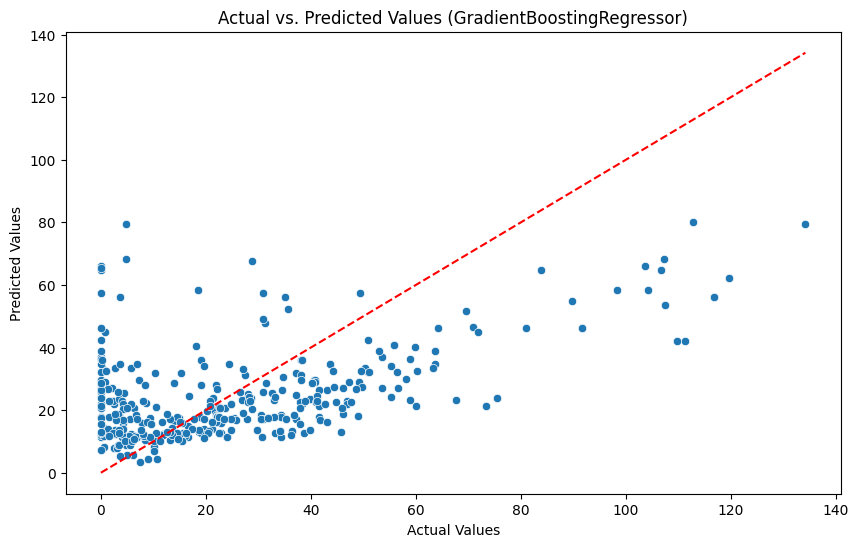

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val_new, y=y_pred_gbr)
plt.title('Actual vs. Predicted Values (GradientBoostingRegressor)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([y_val_new.min(), y_val_new.max()], [y_val_new.min(), y_val_new.max()], color='red', linestyle='--') # Ideal prediction line
plt.show()

In [ ]:
y_pred_gbr_test = gbr_model.predict(test_df_processed)

print("Predictions on the test set using GradientBoostingRegressor:")
print(y_pred_gbr_test)

Predictions on the test set using GradientBoostingRegressor:
[-0.0569249 -0.0569249 -0.0569249 -0.0569249 -0.0569249]


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train the GradientBoostingRegressor model
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train_new, y_train_new)

# Make predictions on the validation set
y_pred_gbr = gbr_model.predict(X_val_new)

# Evaluate the model
mae_gbr = mean_absolute_error(y_val_new, y_pred_gbr)
r2_gbr = r2_score(y_val_new, y_pred_gbr)

print(f"GradientBoostingRegressor - Mean Absolute Error on validation set: {mae_gbr:.4f}")
print(f"GradientBoostingRegressor - R-squared on validation set: {r2_gbr:.4f}")

GradientBoostingRegressor - Mean Absolute Error on validation set: 16.7136
GradientBoostingRegressor - R-squared on validation set: 0.2772


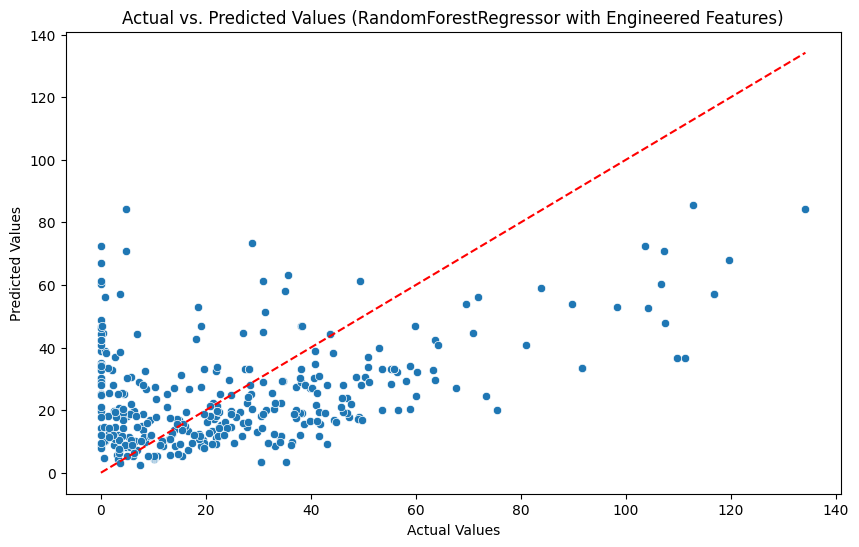

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val_new, y=y_pred_new_features)
plt.title('Actual vs. Predicted Values (RandomForestRegressor with Engineered Features)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([y_val_new.min(), y_val_new.max()], [y_val_new.min(), y_val_new.max()], color='red', linestyle='--') # Ideal prediction line
plt.show()

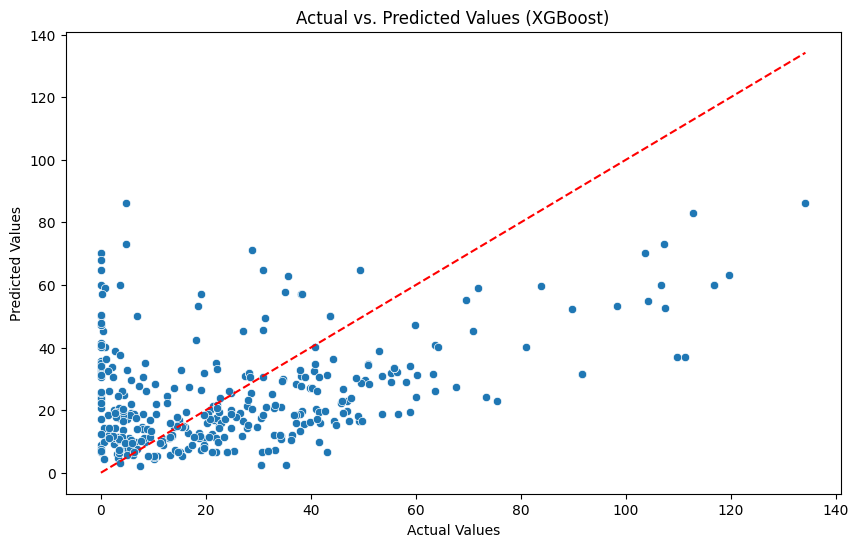

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val_new, y=y_pred_xgb)
plt.title('Actual vs. Predicted Values (XGBoost)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([y_val_new.min(), y_val_new.max()], [y_val_new.min(), y_val_new.max()], color='red', linestyle='--') # Ideal prediction line
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# Initialize the GradientBoostingRegressor model
gbr = GradientBoostingRegressor(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Instantiate GridSearchCV
grid_search_gbr = GridSearchCV(estimator=gbr, param_grid=param_grid_gbr, cv=3, scoring='r2', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search_gbr.fit(X_train_new, y_train_new)

# Print the best parameters found
print("Best parameters found by GridSearchCV:", grid_search_gbr.best_params_)

# Get the best estimator
best_gbr_model = grid_search_gbr.best_estimator_

# Make predictions on the validation set using the best estimator
y_pred_gbr_tuned = best_gbr_model.predict(X_val_new)

# Evaluate the R-squared score
r2_gbr_tuned = r2_score(y_val_new, y_pred_gbr_tuned)
print(f"GradientBoostingRegressor (tuned) - R-squared on validation set: {r2_gbr_tuned:.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found by GridSearchCV: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
GradientBoostingRegressor (tuned) - R-squared on validation set: 0.3180


In [ ]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize LGBMRegressor model
lgbm_model = LGBMRegressor(random_state=42, verbose=-1) # verbose=-1 to suppress verbose output during training

# 2. Initialize CatBoostRegressor model
catboost_model = CatBoostRegressor(random_state=42, verbose=0) # verbose=0 to suppress verbose output during training

# 3. Train LGBMRegressor model
lgbm_model.fit(X_train_new, y_train_new)

# 4. Train CatBoostRegressor model
catboost_model.fit(X_train_new, y_train_new)

# 5. Make predictions on the validation set for LGBMRegressor
y_pred_lgbm = lgbm_model.predict(X_val_new)

# 6. Make predictions on the validation set for CatBoostRegressor
y_pred_catboost = catboost_model.predict(X_val_new)

# 7. Evaluate LGBMRegressor model
mae_lgbm = mean_absolute_error(y_val_new, y_pred_lgbm)
r2_lgbm = r2_score(y_val_new, y_pred_lgbm)

print(f"LGBMRegressor - Mean Absolute Error on validation set: {mae_lgbm:.4f}")
print(f"LGBMRegressor - R-squared on validation set: {r2_lgbm:.4f}")

# 8. Evaluate CatBoostRegressor model
mae_catboost = mean_absolute_error(y_val_new, y_pred_catboost)
r2_catboost = r2_score(y_val_new, y_pred_catboost)

print(f"\nCatBoostRegressor - Mean Absolute Error on validation set: {mae_catboost:.4f}")
print(f"CatBoostRegressor - R-squared on validation set: {r2_catboost:.4f}")

LGBMRegressor - Mean Absolute Error on validation set: 17.7700
LGBMRegressor - R-squared on validation set: 0.1916

CatBoostRegressor - Mean Absolute Error on validation set: 17.9370
CatBoostRegressor - R-squared on validation set: 0.1784


**Reasoning**:
The previous cell failed because the `catboost` library was not found. To resolve this, I need to install `catboost` using `!pip install` before importing it.



In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.3 MB/s eta 0:00:00


**Reasoning**:
Now that `catboost` is successfully installed, I will re-execute the code block to train and evaluate the LightGBM and CatBoost models, as per the subtask instructions.



In [ ]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize LGBMRegressor model
lgbm_model = LGBMRegressor(random_state=42, verbose=-1) # verbose=-1 to suppress verbose output during training

# 2. Initialize CatBoostRegressor model
catboost_model = CatBoostRegressor(random_state=42, verbose=0) # verbose=0 to suppress verbose output during training

# 3. Train LGBMRegressor model
lgbm_model.fit(X_train_new, y_train_new)

# 4. Train CatBoostRegressor model
catboost_model.fit(X_train_new, y_train_new)

# 5. Make predictions on the validation set for LGBMRegressor
y_pred_lgbm = lgbm_model.predict(X_val_new)

# 6. Make predictions on the validation set for CatBoostRegressor
y_pred_catboost = catboost_model.predict(X_val_new)

# 7. Evaluate LGBMRegressor model
mae_lgbm = mean_absolute_error(y_val_new, y_pred_lgbm)
r2_lgbm = r2_score(y_val_new, y_pred_lgbm)

print(f"LGBMRegressor - Mean Absolute Error on validation set: {mae_lgbm:.4f}")
print(f"LGBMRegressor - R-squared on validation set: {r2_lgbm:.4f}")

# 8. Evaluate CatBoostRegressor model
mae_catboost = mean_absolute_error(y_val_new, y_pred_catboost)
r2_catboost = r2_score(y_val_new, y_pred_catboost)

print(f"\nCatBoostRegressor - Mean Absolute Error on validation set: {mae_catboost:.4f}")
print(f"CatBoostRegressor - R-squared on validation set: {r2_catboost:.4f}")

LGBMRegressor - Mean Absolute Error on validation set: 17.7700
LGBMRegressor - R-squared on validation set: 0.1916

CatBoostRegressor - Mean Absolute Error on validation set: 17.9370
CatBoostRegressor - R-squared on validation set: 0.1784


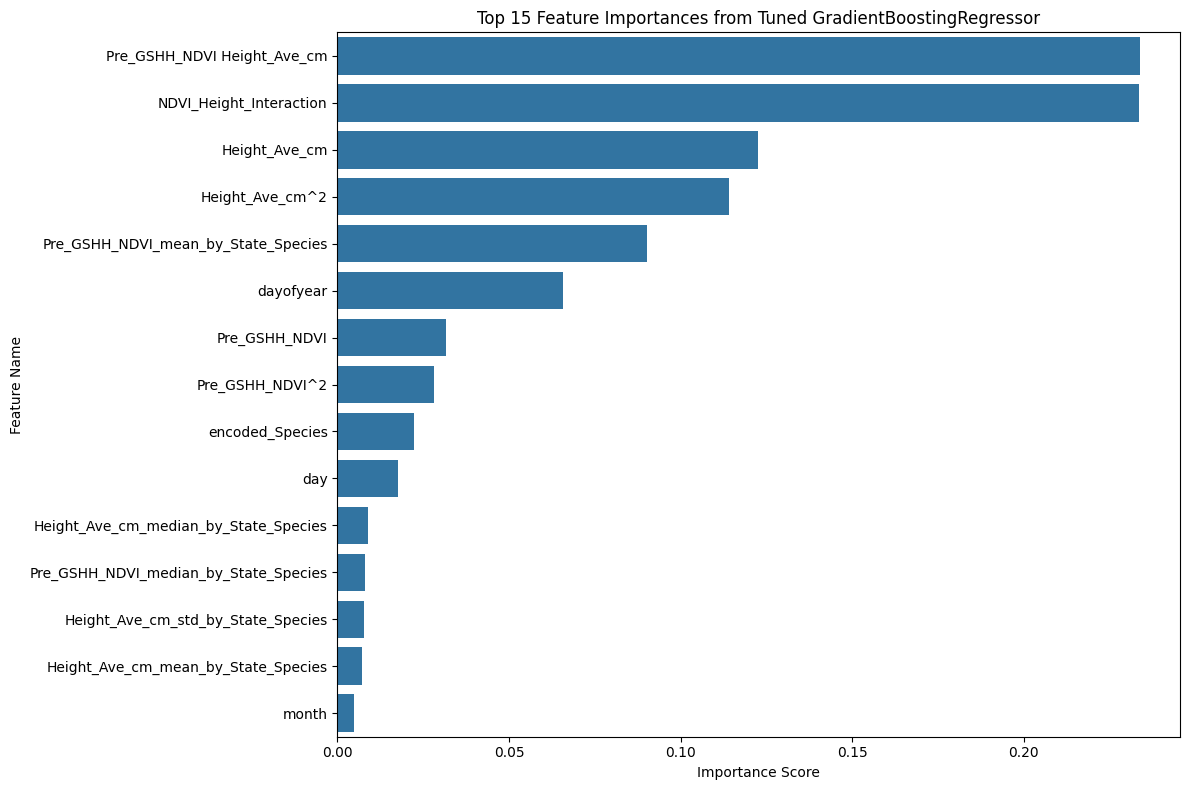

Top 15 features and their importances:


,Feature,Importance
11,Pre_GSHH_NDVI Height_Ave_cm,0.233817
9,NDVI_Height_Interaction,0.233663
1,Height_Ave_cm,0.122661
12,Height_Ave_cm^2,0.114067
13,Pre_GSHH_NDVI_mean_by_State_Species,0.090176
8,dayofyear,0.065656
0,Pre_GSHH_NDVI,0.031702
10,Pre_GSHH_NDVI^2,0.028259
3,encoded_Species,0.022224
6,day,0.017740


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract feature importances from the best_gbr_model
feature_importances = best_gbr_model.feature_importances_

# Get feature names from X_train_new
feature_names = X_train_new.columns

# 2. Create a Pandas DataFrame to store the feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# 3. Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualize the top N most important features (e.g., top 15)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances from Tuned GradientBoostingRegressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()

# 5. Display the plot
plt.show()

print("Top 15 features and their importances:")
display(importance_df.head(15))

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

# 1. Make predictions on the validation set using the trained models
y_pred_gbr_tuned = best_gbr_model.predict(X_val_new)
y_pred_lgbm = lgbm_model.predict(X_val_new)
y_pred_catboost = catboost_model.predict(X_val_new)
y_pred_xgb = xgb_model.predict(X_val_new)
y_pred_rf_engineered = model_new_features.predict(X_val_new)

# 2. Calculate the average of these individual model predictions
y_pred_ensemble_avg = (y_pred_gbr_tuned + y_pred_lgbm + y_pred_catboost + y_pred_xgb + y_pred_rf_engineered) / 5

# 3. Evaluate the R-squared score of this ensemble prediction on the validation set
r2_ensemble_avg = r2_score(y_val_new, y_pred_ensemble_avg)

# 4. Print the R-squared score of the ensemble model
print(f"Ensemble (Average) - R-squared on validation set: {r2_ensemble_avg:.4f}")

Ensemble (Average) - R-squared on validation set: 0.2031


In [ ]:
from sklearn.metrics import r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Re-initialize and train xgb_model with the fully engineered features
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_new, y_train_new)

# Re-initialize and train model_new_features (RandomForestRegressor) with the fully engineered features
model_new_features = RandomForestRegressor(random_state=42)
model_new_features.fit(X_train_new, y_train_new)

# 1. Make predictions on the validation set using the trained models
y_pred_gbr_tuned = best_gbr_model.predict(X_val_new)
y_pred_lgbm = lgbm_model.predict(X_val_new)
y_pred_catboost = catboost_model.predict(X_val_new)
y_pred_xgb = xgb_model.predict(X_val_new)
y_pred_rf_engineered = model_new_features.predict(X_val_new)

# 2. Calculate the average of these individual model predictions
y_pred_ensemble_avg = (y_pred_gbr_tuned + y_pred_lgbm + y_pred_catboost + y_pred_xgb + y_pred_rf_engineered) / 5

# 3. Evaluate the R-squared score of this ensemble prediction on the validation set
r2_ensemble_avg = r2_score(y_val_new, y_pred_ensemble_avg)

# 4. Print the R-squared score of the ensemble model
print(f"Ensemble (Average) - R-squared on validation set: {r2_ensemble_avg:.4f}")

Ensemble (Average) - R-squared on validation set: 0.2031


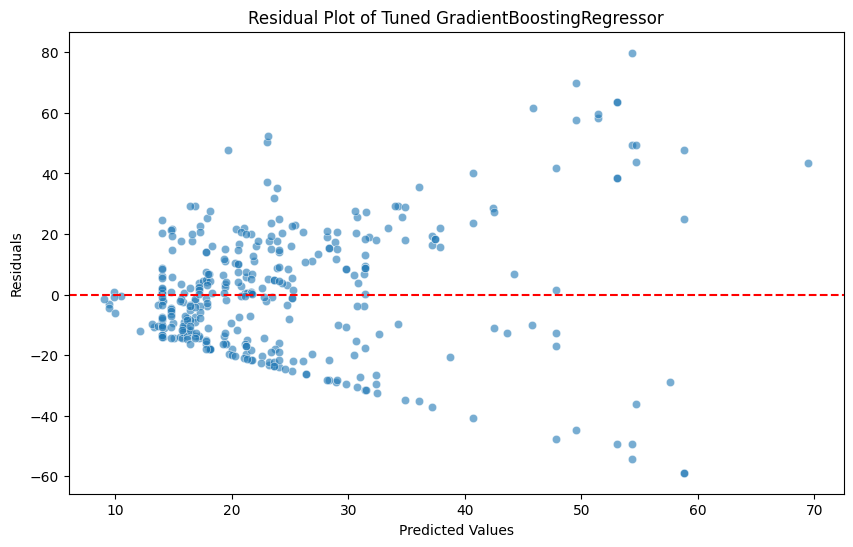

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the residuals
residuals = y_val_new - y_pred_gbr_tuned

# 2. Create a scatter plot with predicted values on the x-axis and residuals on the y-axis
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_gbr_tuned, y=residuals, alpha=0.6)

# 3. Add a horizontal line at y=0
plt.axhline(y=0, color='r', linestyle='--')

# 4. Add appropriate labels for the x and y axes
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# 5. Add a title to the plot
plt.title('Residual Plot of Tuned GradientBoostingRegressor')

# 6. Display the plot
plt.show()